In [2]:
from typing import Iterator

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from pathlib import Path
import json

from torch.nn import Parameter
from torch.utils.data import TensorDataset, DataLoader

from scoit.cell_analysis import umap_visualize
from hgnn.hypergraph import *
from sklearn.preprocessing import MinMaxScaler

/Users/fengcong/miniconda3/envs/py312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from examples.case_studies.sc_GEM_analysis import load_data

expression_data, methylation_data, labels = load_data()

In [4]:
len(labels)

224

In [5]:
def remove_all_nan_columns(data, remove_all_zeros=True):
    print('Input #cols', data.shape[1])
    valid_cols = np.all(~np.isnan(data), axis=0)
    data = data[:, valid_cols]
    print('After remove all nan', data.shape[1])

    if remove_all_zeros:
        # 删除全是0的列。
        valid_cols = ~np.all(data == 0, axis=0)
        data = data[:, valid_cols]
        print('After remove all zeros', data.shape[1])

    return data

In [6]:
expression_data_clean = remove_all_nan_columns(expression_data)
methylation_data_clean = remove_all_nan_columns(methylation_data)

Input #cols 59
After remove all nan 34
After remove all zeros 33
Input #cols 59
After remove all nan 27
After remove all zeros 27


Text(0.5, 1.0, 'methylation_data_clean')

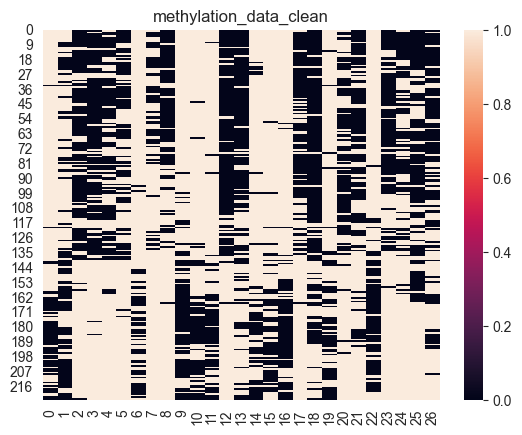

In [7]:
sns.heatmap(methylation_data_clean)
plt.title('methylation_data_clean')

Text(0.5, 1.0, 'expression_data_clean')

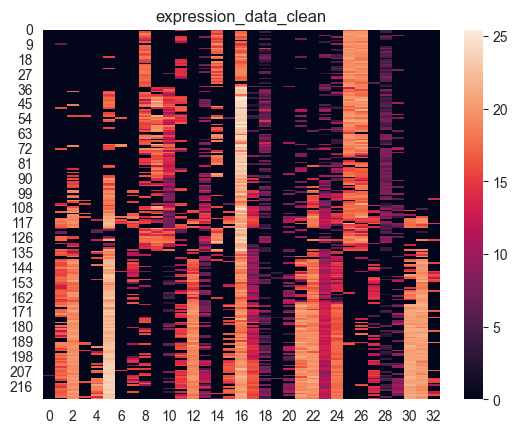

In [8]:
sns.heatmap(expression_data_clean)
plt.title('expression_data_clean')

In [9]:
def get_edges_weights_from_omics(data, omics_id, gene_offset):
    edges = np.nonzero(np.abs(data) > 1e-5)
    weights = data[edges]
    edges = edges + (np.ones_like(edges[0]) * omics_id, )
    edges = np.array(edges).T
    assert np.all(edges.max(0)[:-1] == np.array(data.shape) - 1)
    edges[:, 1] += gene_offset
    return edges, weights

In [10]:
expression_edges, expression_weights = get_edges_weights_from_omics(expression_data_clean, 0, 0)
methylation_edges, methylation_weights = get_edges_weights_from_omics(methylation_data_clean, 1, expression_data_clean.shape[1])

In [11]:
expression_edges.shape, expression_weights.shape, methylation_edges.shape, methylation_weights.shape

((3023, 3), (3023,), (3782, 3), (3782,))

In [12]:
expression_edges.max(0), methylation_edges.max(0)

(array([223,  32,   0]), array([223,  59,   1]))

In [13]:
def concat_edges_weights(edges_list, weights_list):
    return np.concatenate(edges_list, axis=0), np.concatenate(weights_list, axis=0)

In [14]:
edges, weights = concat_edges_weights([expression_edges, methylation_edges], [expression_weights, methylation_weights])

In [15]:
edges.shape, weights.shape

((6805, 3), (6805,))

In [16]:
np.any(weights == 0)

np.False_

In [17]:
save_edges_and_weights('./data/sc_GEM', edges=edges, weights=weights, train_size=0.8, normalization=False)

In [18]:
train_data = np.load('./data/sc_GEM/train_data.npz', allow_pickle=True)
test_data = np.load('./data/sc_GEM/test_data.npz', allow_pickle=True)

In [19]:
train_data['nums_type']

array([224,  60,   2])

In [43]:
!mkdir -p ./embeddings/hgnn/sc_GEM

In [20]:
!rm -rf ./*.npy && python3 hgnn/main_torch_zinb.py --data sc_GEM --feature adj --loss zinb --iter 50 && mv ./*.npy ./embeddings/hgnn/sc_GEM

1.0 -0.5
model_no_randomwalk
Use train_weight (6805,)
Node type num [224  60   2]
embeddings_initial [np.False_, np.False_, np.False_]
[14.181002 14.877033 16.371561 ...  1.        1.        1.      ] 1.0 25.435984
walk type 
adding pad idx
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
dict_size 6805 6805
train data amount 6805
64
tensor([  0, 224, 284, 286], device='mps:0')
w.shape (224, 62)
(224, 62)
w.shape (60, 226)
(60, 226)
w.shape (2, 284)
(2, 284)
self.input_size [62, 226, 284]
inp 62 out 64 weight.shape torch.Size([64, 62])
fan_in 62 7.874007874011811
inp 226 out 64 weight.shape torch.Size([64, 226])
fan_in 226 15.033296378372908
inp 284 out 64 weight.shape torch.Size([64, 284])
fan_in 284 16.852299546352718
params to be trained 119204
batch size 96
[ Epoch 0 of 50 ]
  - (Training)   bce:  0.6520, skipgram:  0.0000, recon:  0.7275 acc: 0.591 %, 

## Analysis

In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scoit.cell_analysis import umap_visualize
from hgnn.hypergraph import *
from hgnn.phasing import *

In [24]:
cell_embeddings = np.load('./embeddings/hgnn/sc_GEM/mymodel_0.npy', allow_pickle=True)
gene_embeddings = np.load('./embeddings/hgnn/sc_GEM/mymodel_1.npy', allow_pickle=True)
omic_embeddings = np.load('./embeddings/hgnn/sc_GEM/mymodel_2.npy', allow_pickle=True)


In [25]:
cell_embeddings.shape

(224, 64)

{'NMI': 0.6509503088345098,
 'ARI': 0.49414961362609305,
 'FMI': 0.5767651500440759}

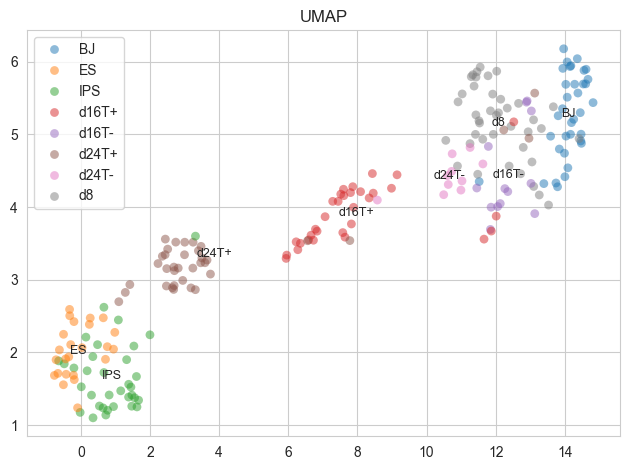

In [26]:
umap_visualize(cell_embeddings, labels)

## Phasing

In [27]:
G = torch.tensor(gene_embeddings, dtype=torch.float)
C = torch.tensor(cell_embeddings, dtype=torch.float)
O = torch.tensor(omic_embeddings, dtype=torch.float)
X = torch.tensor(np.concatenate([expression_data_clean, methylation_data_clean], axis=1), dtype=torch.float)

In [28]:
L = build_laplacian(C)

torch.trace(X.T @ L @ X)

tensor(120474.2500)

<Axes: >

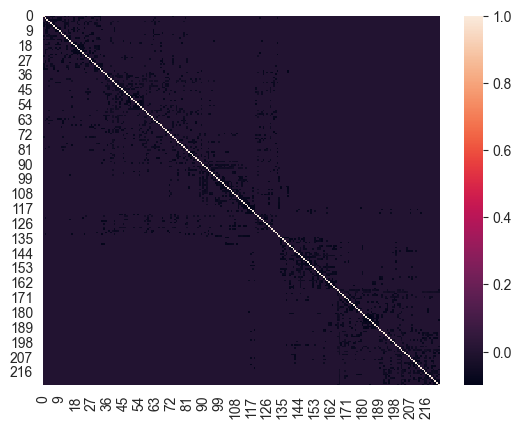

In [29]:
sns.heatmap(L)

In [30]:
np.min(np.linalg.eigvalsh(L))

np.float32(1.8636297e-09)

In [31]:
epochs = 5000
embed_dim = C.shape[1]
# 超参，按需要调
alpha = 0.001
k = 3
lr = 1e-3
omics_offset = expression_data_clean.shape[1]
num_cells = C.shape[0]
num_genes = G.shape[0]
embed_dim, omics_offset

(64, 33)

In [32]:
model, histories = train_phasing_model(
    embed_dim=embed_dim,
    omics_offset=omics_offset,
    epochs=epochs,
    lr=lr,
    k=k,
    alpha=alpha,
    C=C, G=G, O=O, X=X,
)

Epoch   0  total=246.740  rec=143.945  reg=102794.961
Epoch 100  total=52.382  rec=32.827  reg=19555.127
Epoch 200  total=44.439  rec=27.708  reg=16730.943
Epoch 300  total=38.425  rec=23.999  reg=14426.210
Epoch 400  total=34.049  rec=21.404  reg=12644.516
Epoch 500  total=31.622  rec=19.634  reg=11987.953
Epoch 600  total=29.725  rec=18.223  reg=11502.744
Epoch 700  total=27.896  rec=17.105  reg=10790.805
Epoch 800  total=26.606  rec=16.430  reg=10176.690
Epoch 900  total=25.870  rec=15.975  reg=9895.015
Epoch 1000  total=25.350  rec=15.609  reg=9741.049
Epoch 1100  total=24.940  rec=15.309  reg=9630.919
Epoch 1200  total=24.602  rec=15.057  reg=9544.930
Epoch 1300  total=24.318  rec=14.836  reg=9481.998
Epoch 1400  total=24.055  rec=14.633  reg=9422.229
Epoch 1500  total=23.836  rec=14.449  reg=9386.479
Epoch 1600  total=23.631  rec=14.274  reg=9356.852
Epoch 1700  total=23.441  rec=14.108  reg=9332.746
Epoch 1800  total=23.267  rec=13.956  reg=9310.761
Epoch 1900  total=23.108  rec

Text(0.5, 1.0, 'Phasing Loss vs Epoch')

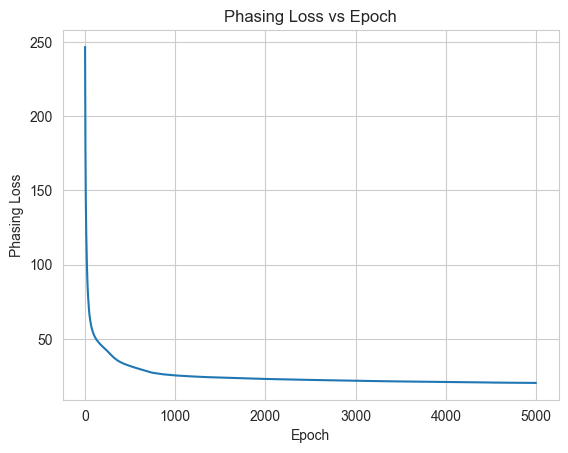

In [33]:
plt.plot(histories['history'])
plt.xlabel('Epoch')
plt.ylabel('Phasing Loss')
plt.title('Phasing Loss vs Epoch')

Text(0.5, 1.0, 'Reconstruction Loss vs Epoch')

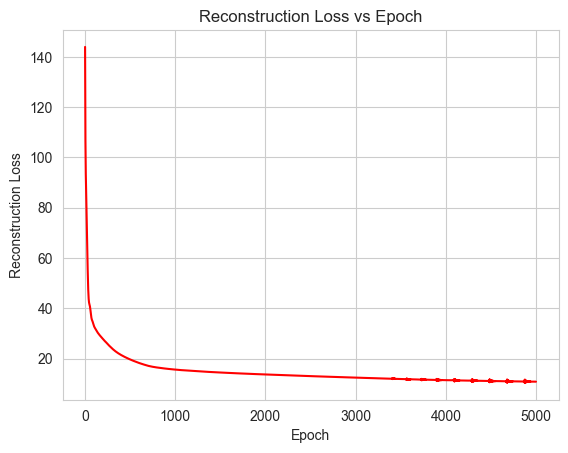

In [34]:
plt.plot(histories['history_recon'], color='red')
plt.xlabel('Epoch')
plt.ylabel('Reconstruction Loss')
plt.title('Reconstruction Loss vs Epoch')

Text(0.5, 1.0, 'Regularization Loss vs Epoch')

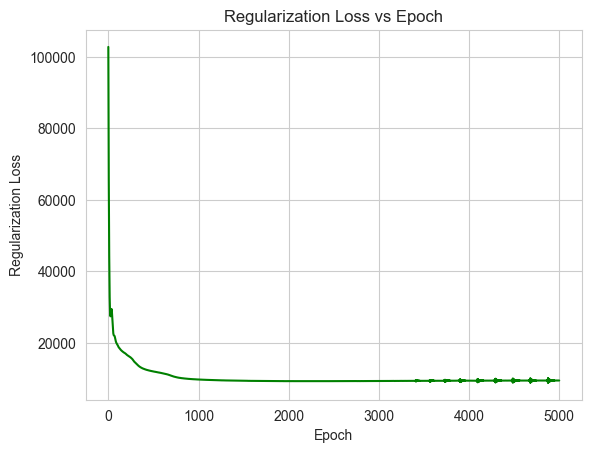

In [35]:
plt.plot(histories['history_reg'], color='green')
plt.xlabel('Epoch')
plt.ylabel('Regularization Loss')
plt.title('Regularization Loss vs Epoch')

In [36]:
Xp0, Xp1, Xm0, Xm1 = model.predict(G, C, O)

Text(0.5, 1.0, 'X1')

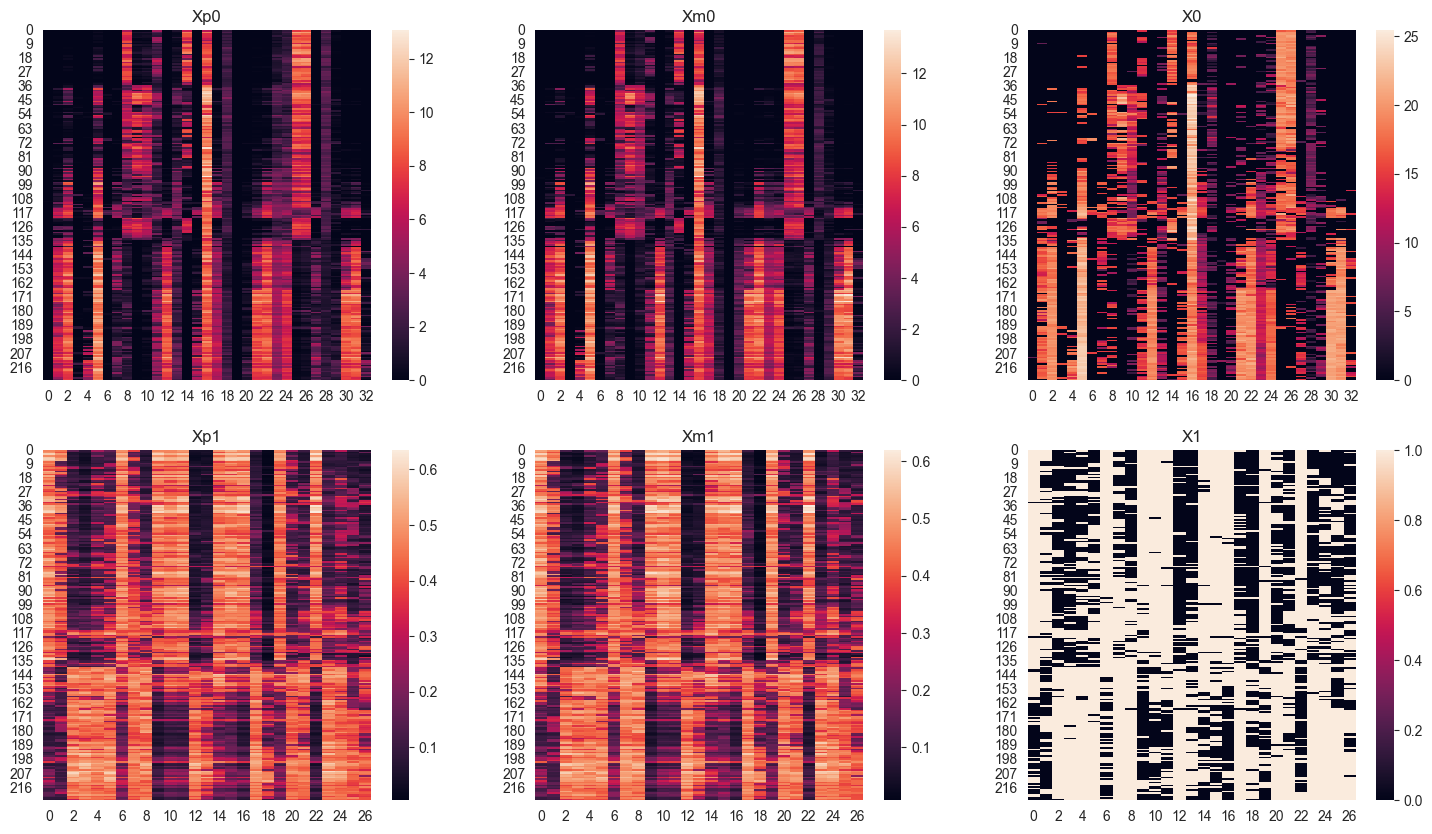

In [37]:
plt.figure(figsize=(18,10))
ax = plt.subplot(231)
sns.heatmap(Xp0,ax=ax)
plt.title('Xp0')
ax = plt.subplot(232)
sns.heatmap(Xm0,ax=ax)
plt.title('Xm0')
ax = plt.subplot(233)
sns.heatmap(expression_data_clean,ax=ax)
plt.title('X0')
ax = plt.subplot(234)
sns.heatmap(Xp1,ax=ax)
plt.title('Xp1')
ax = plt.subplot(235)
sns.heatmap(Xm1,ax=ax)
plt.title('Xm1')
ax = plt.subplot(236)
sns.heatmap(methylation_data_clean,ax=ax)
plt.title('X1')

{'NMI': 0.6125637140965615,
 'ARI': 0.47245545043965326,
 'FMI': 0.549235706535178}

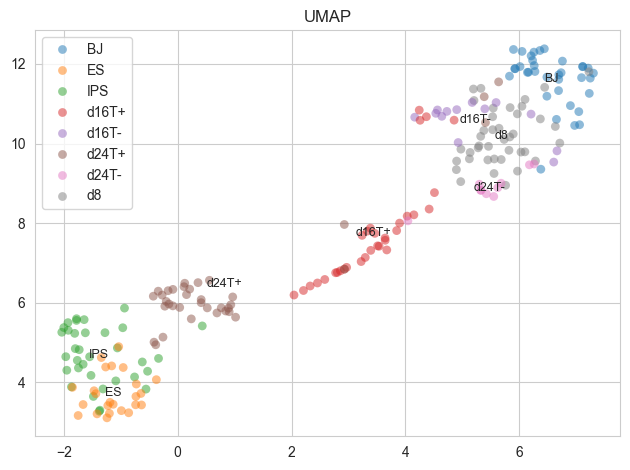

In [38]:
umap_visualize(C, labels)

{'NMI': 0.6092684898306431,
 'ARI': 0.4714879412191635,
 'FMI': 0.549122591340007}

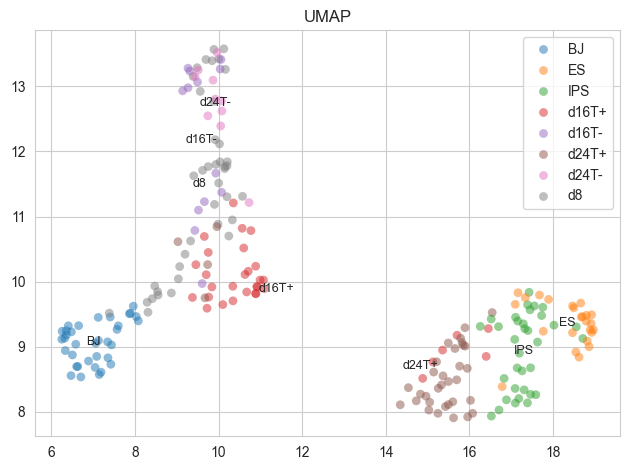

In [39]:
umap_visualize(Xp0, labels)


{'NMI': 0.6120153027413343,
 'ARI': 0.4789856768327797,
 'FMI': 0.5541735569714749}

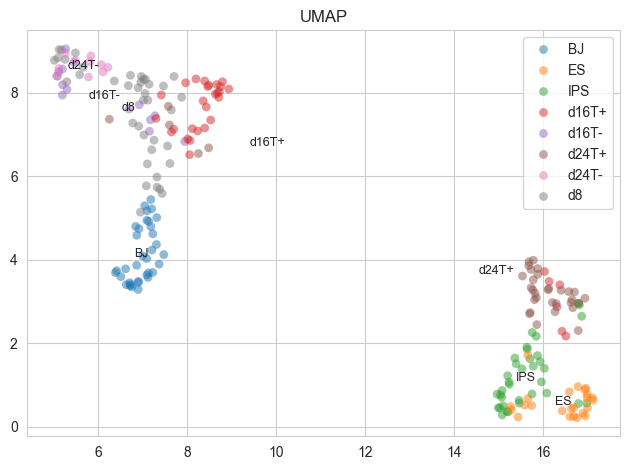

In [40]:
umap_visualize(Xm0, labels)


{'NMI': 0.3918358984935201,
 'ARI': 0.21433640986663682,
 'FMI': 0.32338133880723663}

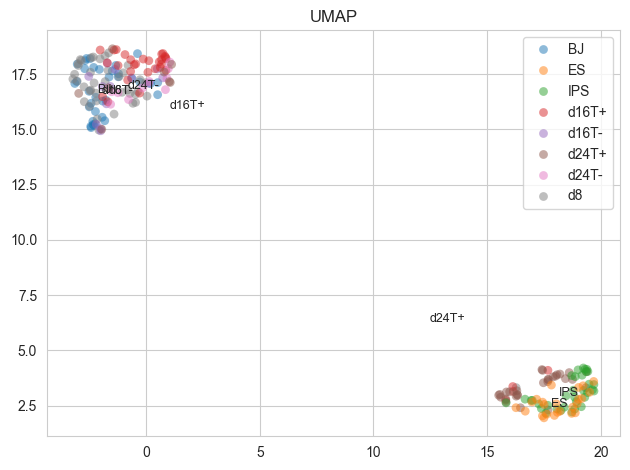

In [41]:
umap_visualize(Xp1, labels)


{'NMI': 0.3928702745568962,
 'ARI': 0.22400648138918205,
 'FMI': 0.3381945497574087}

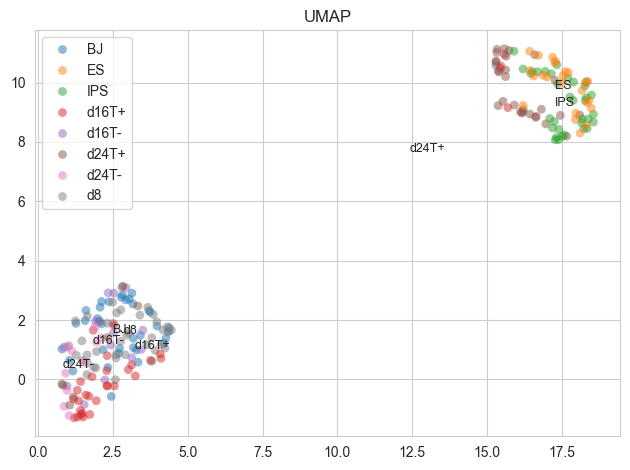

In [42]:
umap_visualize(Xm1, labels)
